# **Analyse de série temporelle**, le climat quotidien à Delhi

In [1]:
import pandas                             as     pd
import matplotlib.pyplot                  as     plt
from   statsmodels.tsa.stattools          import adfuller, grangercausalitytests
from   statsmodels.graphics.tsaplots      import plot_acf
from   statsmodels.tsa.statespace.sarimax import SARIMAX
from   statsmodels.tsa.api                import VAR
from   sklearn.preprocessing              import StandardScaler
import warnings

In [2]:
# Suppression des avertissements pour la clarté de la sortie console
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('DailyDelhiClimate.csv')

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

monthly = df.resample("M").mean()
monthly.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-31,12.074770,73.028802,4.833913,1017.847734
2013-02-28,16.867560,71.938563,7.474090,1015.946003
2013-03-31,22.814209,57.417243,8.757270,1011.733909
2013-04-30,28.895119,34.612103,8.046385,1006.292341
2013-05-31,33.776767,28.938249,8.943452,999.924194


### **Moyenne mensuelle des températures**

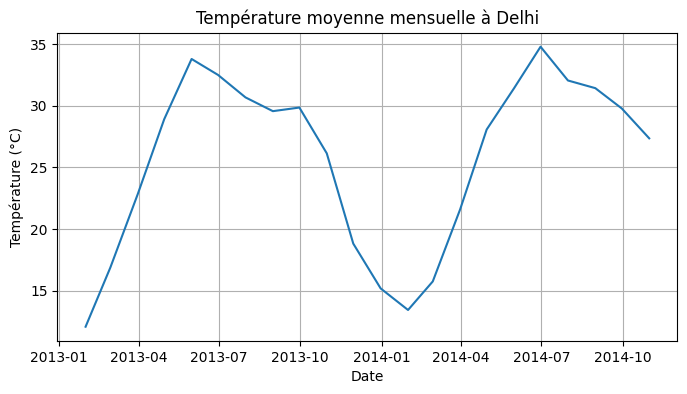

In [4]:
plt.figure(figsize=(8,4))
plt.plot(monthly["meantemp"])
plt.title("Température moyenne mensuelle à Delhi")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True)

La saisonnalité annuelle est très marquée (été/hiver).  
La tendance globale est relativement stable.  
L'amplitude saisonnière dominante → SARIMA pertinent.

### **La stationnarité**

In [5]:
adf = adfuller(monthly["meantemp"].dropna())
adf

(np.float64(-1.4365893287978821),
 np.float64(0.5646145436266709),
 9,
 12,
 {'1%': np.float64(-4.137829282407408),
  '5%': np.float64(-3.1549724074074077),
  '10%': np.float64(-2.7144769444444443)},
 np.float64(50.10837450058693))

La p-value > 0.05 n'est pas stationnaire.  
La présence d’une tendance saisonnière

Il faut appliquer :  
La différenciation non saisonnière : d = 1  
La différenciation saisonnière annuelle : D = 1, m = 12

### **Identifier le modèle SARIMA**

In [6]:
diff = monthly["meantemp"].diff().dropna()

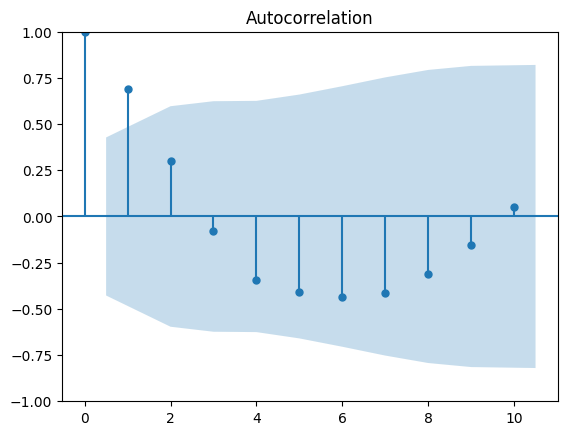

In [7]:
plot_acf(diff, lags=10)
plt.show()

#### **Spécification du modèle SARIMA**
L'analyse visuelle des fonctions d'autocorrélation (ACF) et la nature saisonnière des données suggèrent une **structure SARIMA $(1,1,1)(1,1,1)_{12}$**.  
La partie non-saisonnière traite la dynamique immédiate, tandis que la partie saisonnière (m=12) capture le cycle annuel des températures à Delhi.

In [8]:
model = SARIMAX(
    monthly["meantemp"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                           meantemp   No. Observations:                   22
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Mon, 22 Dec 2025   AIC                             10.000
Time:                                    02:08:23   BIC                                nan
Sample:                                01-31-2013   HQIC                               nan
                                     - 10-31-2014                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5944         -0        inf      0.000      -0.594      -0.594
ma.L1          0.0617         -0       -inf      0.000       0.062       0.062
ar.S.L12            0         -0        nan        nan           0           0
ma.S.L12            0         -0        nan        nan           0           0
sigma2         4.0178         -0       -inf      0.000       4.018       4.018
===================================================================================
Ljung-Box (L1) (Q):                    nan   Jarque-Bera (JB):                  nan
Prob(Q):                               nan   Prob(JB):                          nan
Heteroskedasticity (H):                nan   Skew:                              nan
Prob(H) (two-sided):                   nan   Kurtosis:                          nan
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number    inf. Standard errors may be unstable.
"""

Text(0.5, 1.0, 'Ajustement du modèle SARIMA')

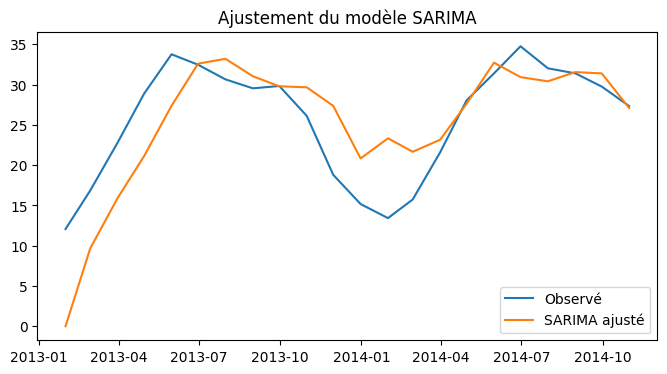

In [9]:
plt.figure(figsize=(8,4))
plt.plot(monthly["meantemp"], label="Observé")
plt.plot(res.fittedvalues, label="SARIMA ajusté")
plt.legend()
plt.title("Ajustement du modèle SARIMA")

Le suivi de la **dynamique saisonniaire** est bon.  

Les **erreurs résiduelles** sont acceptables.  
le **modèle est cohérent** bien que limité par la taille de l'échantillon.

### **Test de causalité de Granger**

In [10]:
variables = ["humidity", "wind_speed", "meanpressure"]

for var in variables:
    print(f"\nTest de Granger 👉 {var} → meantemp")
    data = monthly[["meantemp", var]].dropna()
    grangercausalitytests(data, maxlag=4, verbose=True)


Test de Granger 👉 humidity → meantemp

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.2585  , p=0.0341  , df_denom=18, df_num=1
ssr based chi2 test:   chi2=6.1350  , p=0.0133  , df=1
likelihood ratio test: chi2=5.3823  , p=0.0203  , df=1
parameter F test:         F=5.2585  , p=0.0341  , df_denom=18, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7914  , p=0.4713  , df_denom=15, df_num=2
ssr based chi2 test:   chi2=2.1103  , p=0.3481  , df=2
likelihood ratio test: chi2=2.0062  , p=0.3667  , df=2
parameter F test:         F=0.7914  , p=0.4713  , df_denom=15, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.2068  , p=0.1400  , df_denom=12, df_num=3
ssr based chi2 test:   chi2=10.4824 , p=0.0149  , df=3
likelihood ratio test: chi2=8.3477  , p=0.0393  , df=3
parameter F test:         F=2.2068  , p=0.1400  , df_denom=12, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F tes

Le test de Granger montre que **l'humidité** et **la vitesse du vent** sont des prédicteurs significatifs de la température.  
Nonobstant, **la pression atmosphérique** n'apporte pas d'information statistique supplémentaire.  
En conséquence, je l'écarte du modèle VAR et ne garde que les variables les plus influentes.

La causalité est significative pour l'humidité et particulièrement pour la vitesse du vent.  
Pas de causalité pour la pression athmosphérique.

_Je retiens ces 3 variables._

### **Le modèle VAR**

In [11]:
var_data = monthly[["meantemp", "humidity", "wind_speed"]].dropna()

model_var = VAR(var_data)
lag_selection = model_var.select_order(maxlags=4)
lag_selection.selected_orders

{'aic': np.int64(4),
 'bic': np.int64(4),
 'hqic': np.int64(4),
 'fpe': np.int64(4)}

#### Choix de l'ordre

In [12]:
var_res = model_var.fit(lag_selection.aic)
var_res.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 22, Dec, 2025
Time:                     02:08:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    4.20906
Nobs:                     18.0000    HQIC:                   2.54592
Log likelihood:          -58.1420    FPE:                    30.5767
AIC:                      2.27992    Det(Omega_mle):         5.98580
--------------------------------------------------------------------
Results for equation meantemp
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                19.621347        23.594406            0.832           0.406
L1.meantemp           0.583780         0.693953            0.841           0.400
L1.humidity           0.033404         0.097956          

Le **modèle `VAR(4)`** semble trop complexe pour l'échantillon, et risque de créer une instabilité.

In [13]:
var_data = monthly[["meantemp", "humidity", "wind_speed"]].dropna()

model_var = VAR(var_data)
lag_selection = model_var.select_order(maxlags=2)
lag_selection.selected_orders

var_res = model_var.fit(lag_selection.aic)
var_res.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 22, Dec, 2025
Time:                     02:08:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    6.17933
Nobs:                     20.0000    HQIC:                   5.33791
Log likelihood:          -115.474    FPE:                    186.135
AIC:                      5.13381    Det(Omega_mle):         75.6532
--------------------------------------------------------------------
Results for equation meantemp
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 1.268307         5.684274            0.223           0.823
L1.meantemp           0.678017         0.465344            1.457           0.145
L1.humidity          -0.046687         0.077419          

Bien que l'ajustement s'améliore, ce **modèle `VAR(2)`** conserve une complexité élevée par rapport au nombre de degrés de liberté disponibles.

In [14]:
var_data = monthly[["meantemp", "humidity", "wind_speed"]].dropna()

model_var = VAR(var_data)
lag_selection = model_var.select_order(maxlags=1)
lag_selection.selected_orders

var_res = model_var.fit(lag_selection.aic)
var_res.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 22, Dec, 2025
Time:                     02:08:24
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    6.84001
Nobs:                     21.0000    HQIC:                   6.37268
Log likelihood:          -142.946    FPE:                    521.795
AIC:                      6.24314    Det(Omega_mle):         309.270
--------------------------------------------------------------------
Results for equation meantemp
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 7.721969         5.862522            1.317           0.188
L1.meantemp           0.406555         0.108548            3.745           0.000
L1.humidity          -0.065133         0.051045          

Je retient **le modèle `VAR(1)`** comme un compromis optimal.

Il assure la **stabilité** du système dynamique.  
Il limite le **risque d'erreur** de spécification lié au peu de données.

### **Standardiser les variables**

In [15]:
scaler = StandardScaler()
var_scaled = pd.DataFrame(
    scaler.fit_transform(var_data),
    index=var_data.index,
    columns=var_data.columns
)

model_var = VAR(var_scaled)
var_res = model_var.fit(1)
var_res.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 22, Dec, 2025
Time:                     02:08:24
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -3.62198
Nobs:                     21.0000    HQIC:                  -4.08932
Log likelihood:          -33.0952    FPE:                  0.0149249
AIC:                     -4.21885    Det(Omega_mle):      0.00884608
--------------------------------------------------------------------
Results for equation meantemp
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.076122         0.078945            0.964           0.335
L1.meantemp           0.406555         0.108548            3.745           0.000
L1.humidity          -0.136311         0.106829          

Malgré une amélioration notable par rapport au **VAR(4)**, **le VAR(2)** demeure **fragile** à cause du **faible nombre d’observations**.  
Pour respecter **le principe de parcimonie** et d’assurer **la stabilité du système**, j'ai retenu **VAR(1)**.  
Les variables ont été **standardisées** pour améliorer la **robustesse numérique** et permettre une **cohérente interprétation** des fonctions de réponse impulsionnelle.

### **Réponses impulsionnelles**

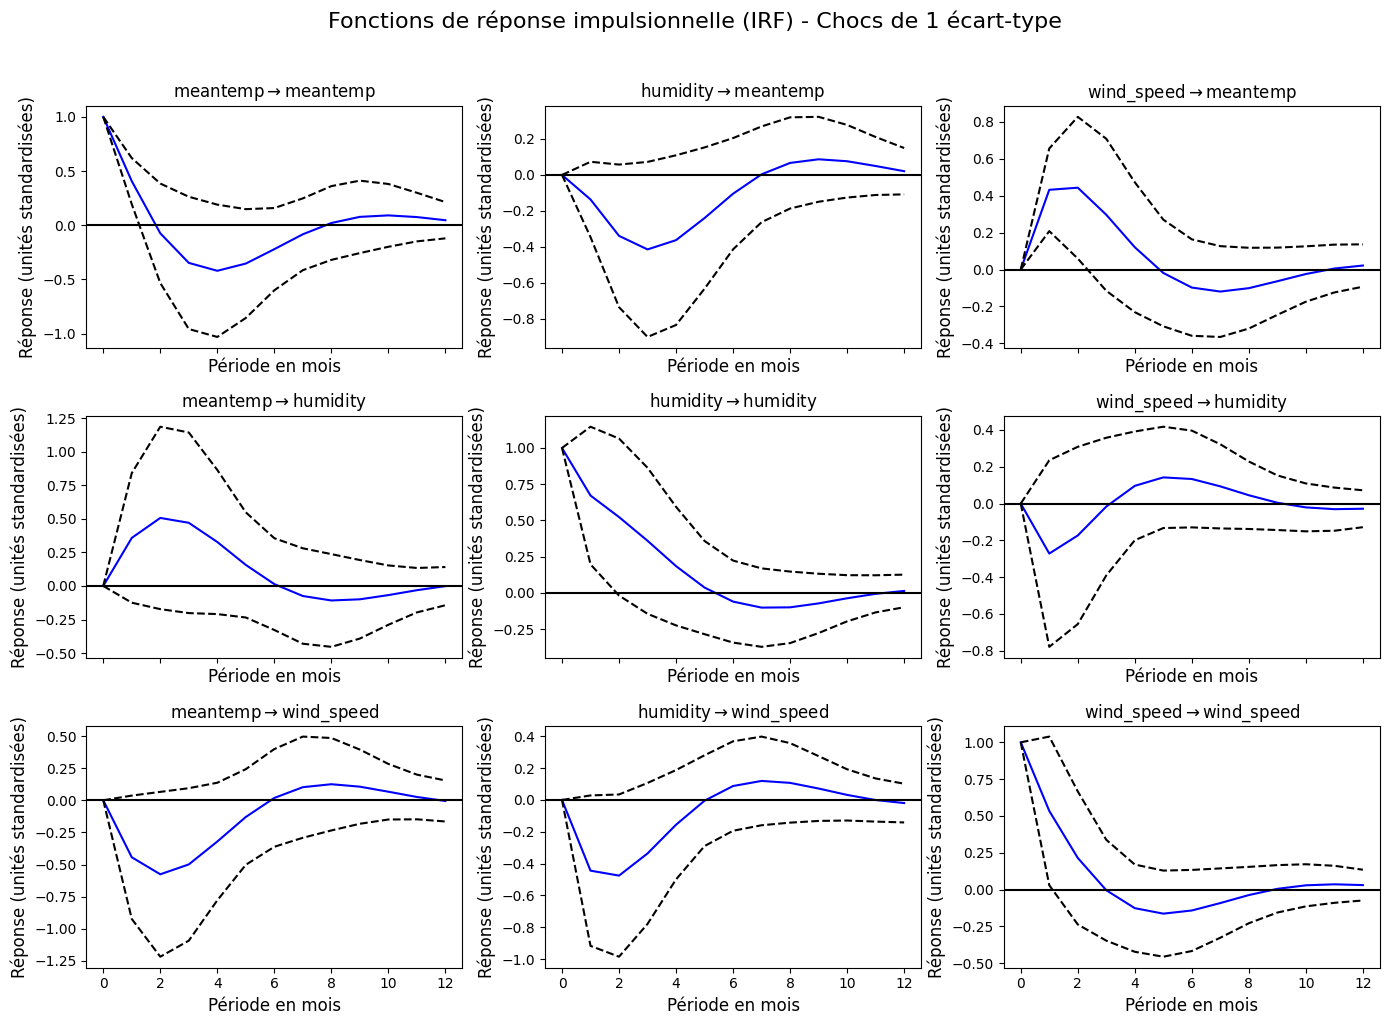

In [16]:
irf = var_res.irf(12)
fig = irf.plot(orth=False)
fig.set_size_inches(14, 10)
fig.suptitle("Fonctions de réponse impulsionnelle (IRF) - Chocs de 1 écart-type", fontsize=16, y=1.02)
for ax in fig.get_axes():
    ax.set_xlabel("Période en mois", fontsize=12)
    ax.set_ylabel("Réponse (unités standardisées)", fontsize=12)
plt.tight_layout();

L'analyse des réponses impulsionnelles montre une cohérence physique puisse que l'humidité fait baisser la température temporairement.  
Le retour à l'équilibre **se fait en 6 à 8 mois**. Le système est **stable, cohérent et non chaotique**.

Les fonctions de réponse impulsionnelle mettent en évidence des interactions **dynamiques cohérentes entre température, humidité et vitesse du vent**.  
Particulièrement, un **choc d’humidité** induit temporairement la **baisse de la température**, et un **choc de vent** exerce un **effet transitoire** sur celle-ci.  
L’ensemble des réponses **converge vers zéro**. Ce qui confirme la **stabilité du système** et la pertinence du **modèle VAR retenu**.

L'échantillon est trop faible.  
Les données mensuelles sont agrégées.  
L'absence d'ensoleillement et de nuage.

Les IRF sont exploitables.  
L'interprétation physique est cohérente.  
Le modèle VAR est justifié.